In [2]:
%pip install geopandas
%pip install matplotlib
import geopandas as gpd
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


The point of this project is to look at public service requests (potholes broken sidewalk etc.) within the bounds of the town of Chapel Hill and relate them to bike infrastructure (such as bike trails and paved paths in parks). The point of this is to identify what problems may be impacting people more, AKA what problems require more immediate attention. Additionally looking at this can speak to the volume of requests vs the location of the problem, which can show, broadly, the traffic that goes through there. (I thought of this because I was biking at North Cary Park and my friend wiped out on a pothole)

In [ ]:
bikes = gpd.read_file("data/BikeInfrastructure.geojson")
requests = gpd.read_file("data/PublicServiceRequests.geojson")
town = gpd.read_file("data/Jurisdictional_Limits.geojson")


In [4]:
bikes = bikes.to_crs("EPSG:2264")
requests = requests.to_crs("EPSG:2264")
town = town.to_crs("EPSG:2264")

In [7]:
bike_buffer = bikes.copy()

bike_buffer["geometry"] = bikes.buffer(1320)

bike_buffer = bike_buffer.dissolve()

bike_access = gpd.clip(
    bike_buffer,
    town
)

bike_access.to_file(
    "data/bike_access.geojson",
    driver="GeoJSON"
)

This buffer allows us to see areas "near" the bike paths to ensure we capture issues that are relatively nearby (1/4 mile). Then we dissolved the buffer to ensure that the areas dont overlap and give us confusing or incorrect information. After this we clipped the buffers to the town of chapel hill to ensure we don't capture anything outside of this jurisdiction.

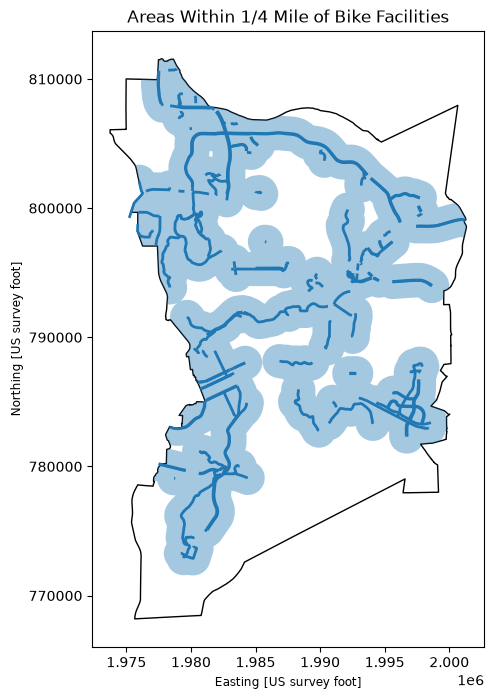

In [8]:
ax = town.plot(
    figsize=(10, 8),
    facecolor="none",
    edgecolor="black"
)

bike_access.plot(
    ax=ax,
    alpha=0.4
)

bikes.plot(
    ax=ax,
    linewidth=2
)

plt.title("Areas Within 1/4 Mile of Bike Facilities")
plt.show()

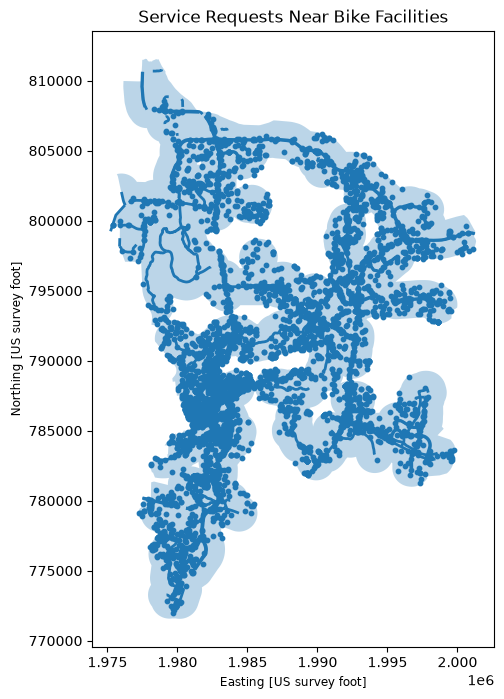

In [11]:
requests_near_bikes = gpd.sjoin(
    requests,
    bike_access,
    predicate="within",
    how="inner"
)

ax = bike_access.plot(
    figsize=(10, 8),
    alpha=0.3
)

bikes.plot(
    ax=ax,
    linewidth=2
)

requests_near_bikes.plot(
    ax=ax,
    markersize=10
)

plt.title("Service Requests Near Bike Facilities")
plt.show()

Using the buffers we created a spatial join to find which serice requests are within 1/4 mile of a bike path or trail. This allows us to see the scale of the problem (a lot of data). We can see that a lot of requests are near bike paths and we can see that these problems are concentrated in certain areas vs others (could be due to traffic or conditions).

In [12]:
requests_join = gpd.sjoin(
    requests,
    bike_access,
    predicate="within",
    how="left"
)

requests_outside = requests_join[
    requests_join["index_right"].isna()
].copy()

requests_outside = requests_outside.drop(
    columns="index_right"
)

requests_nearest_bike = gpd.sjoin_nearest(
    requests_outside,
    bikes,
    how="left",
    distance_col="distance_ft"
)

requests_nearest_bike["distance_miles"] = (
    requests_nearest_bike["distance_ft"] / 5280
)

requests_nearest_bike.to_file(
    "data/requests_nearest_bike.geojson",
    driver="GeoJSON"
)

requests_nearest_bike[
    ["distance_ft", "distance_miles"]
].head()

,distance_ft,distance_miles
1,2445.534822,0.463169
6,1406.284751,0.266342
9,1477.929241,0.279911
21,1423.375779,0.269579
23,1336.639258,0.253151


Finally we cut down the data to just the service requests further than a 1/4 mile from bike infrastructure. This allows us to see any relation between these bike trails and these service requests (maybe there are less reports in further places because of less traffic. Or maybe there are less problems in general because of less people)

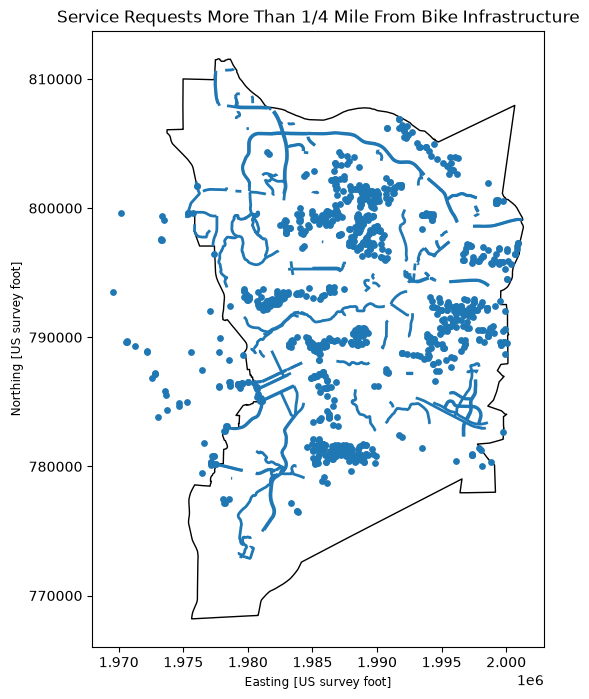

In [13]:
ax = town.plot(
    figsize=(10, 8),
    facecolor="none",
    edgecolor="black"
)

bikes.plot(
    ax=ax,
    linewidth=2
)

requests_nearest_bike.plot(
    ax=ax,
    markersize=15
)

plt.title("Service Requests More Than 1/4 Mile From Bike Infrastructure")
plt.show()

The map shows some are outside of the chapel hill boundary (hence we do not care about them). Additionally this shows us that there are a lot fewer requests further from this infrastructure (could just be because bike infrastructure covers so much of Chapel Hill)